<a href="https://colab.research.google.com/github/PhoenixKnight-in/IDS_NDL_Data_set/blob/main/IDS_NDL_Kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
import time
import pickle
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
from sklearn.feature_selection import SelectFromModel


In [ ]:
cols = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "class",
    "difficulty_level"
]



df = pd.read_csv("KDDTrain+.txt",names = cols)
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [ ]:
df_train = pd.read_csv('KDDTrain+.txt',names=cols,header=None)
df_test = pd.read_csv('KDDTest+.txt',names=cols,header=None)
print(f"Training shape: {df_train.shape}")
print(f"Testing shape: {df_test.shape}")


Training shape: (125973, 43)
Testing shape: (22544, 43)


In [ ]:
# Remove difficulty_level (not needed for prediction)
df_train = df_train.drop('difficulty_level', axis=1)
df_test = df_test.drop('difficulty_level', axis=1)

In [ ]:
#Convert multiple attack types into a simple binary classification: 0 = normal, 1 = attack
df_train['is_attack'] = df_train['class'].apply(lambda x: 0 if x == 'normal' else 1 )
df_test['is_attack'] = df_test['class'].apply(lambda x: 0 if x == 'normal' else 1 )
print(df_train['is_attack'].value_counts())

is_attack
0    67343
1    58630
Name: count, dtype: int64


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [ ]:
# Find categorical columns
categorical_cols = ['protocol_type', 'service', 'flag']

# Encode them
label_encoders = {}
for col in categorical_cols:
  le = LabelEncoder()
  # Fit on combined data to handle all categories
  combined = pd.concat([df_train[col], df_test[col]]).unique()
  le.fit(combined)
  df_train[col] = le.transform(df_train[col])
  df_test[col] = le.transform(df_test[col])
  label_encoders[col] = le
print("Categorical variables encoded!")

Categorical variables encoded!


In [ ]:
# Removing Duplicates
print(f"Duplicates: {df_train.duplicated().sum()}")

Duplicates: 0


In [ ]:
# Handling Outliers
# Outliers are extreme values that can hurt model performance. We'll 'cap' them using the IQR (Interquartile Range) method:
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('is_attack')
# Cap outliers for each column
for col in numeric_cols:
  Q1 = df_train[col].quantile(0.25)
  Q3 = df_train[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 3 * IQR
  upper_bound = Q3 + 3 * IQR
  # Cap values to bounds
  df_train[col] = df_train[col].clip(lower=lower_bound, upper=upper_bound)
  df_test[col] = df_test[col].clip(lower=lower_bound, upper=upper_bound)
print("Outliers handled!")


Outliers handled!


Feature Engineering

In [ ]:
# Separate features (X) and target (y)
X_train = df_train.drop(['class', 'is_attack'], axis=1)
y_train = df_train['is_attack']
X_test = df_test.drop(['class', 'is_attack'], axis=1)
y_test = df_test['is_attack']
print(f"Features shape: {X_train.shape}")
print(f"Target shape: {y_train.shape}")

Features shape: (125973, 41)
Target shape: (125973,)


In [ ]:
# Standardize feature (mean=0,std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled successfully!")

Features scaled successfully!


Train the Model Linear Regression

In [ ]:
# Create and train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
  # Make predictions
y_pred_continuous = lr_model.predict(X_test_scaled)
  # Convert to binary (0 or 1) using 0.5 threshold
y_pred_lr = (y_pred_continuous > 0.5).astype(int)
print("Linear Regression trained!")

Linear Regression trained!


Evaluation Performance

In [ ]:
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

           0       0.63      0.92      0.75      9711
           1       0.91      0.58      0.71     12833

    accuracy                           0.73     22544
   macro avg       0.77      0.75      0.73     22544
weighted avg       0.79      0.73      0.72     22544



Naive Bayes

In [ ]:
# Create and train Naive Bayes model
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
# Make predictions
y_pred_nb = nb_model.predict(X_test_scaled)
print("Naive Bayes trained!")

Naive Bayes trained!


In [ ]:
print(classification_report(y_test,y_pred_nb))

              precision    recall  f1-score   support

           0       0.65      0.94      0.77      9711
           1       0.93      0.62      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.79      0.78      0.75     22544
weighted avg       0.81      0.75      0.75     22544



SVM (Support Vector Machine with linear Kernel)

In [ ]:
# Creating SVM model and training
svm_model = SVC()
svm_model = svm_model.fit(X_train_scaled,y_train)
# Making predictions
y_pred_svm = svm_model.predict(X_test_scaled)
print(classification_report(y_test,y_pred_svm))

              precision    recall  f1-score   support

           0       0.69      0.96      0.80      9711
           1       0.96      0.67      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.82      0.82      0.80     22544
weighted avg       0.84      0.80      0.80     22544



SVM with RBF Kernel

In [ ]:
#Train with default RBF
svm_default = SVC(kernel='rbf')
svm_default.fit(X_train_scaled, y_train)
y_pred_rbf = svm_default.predict(X_test_scaled)

print(classification_report(y_test,y_pred_rbf))

              precision    recall  f1-score   support

           0       0.69      0.96      0.80      9711
           1       0.96      0.67      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.82      0.82      0.80     22544
weighted avg       0.84      0.80      0.80     22544



In [ ]:
# 3. Grid Search for best parameters
param_grid = {
    'C': [1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 'scale']
}
grid_search = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=3)
grid_search.fit(X_train_scaled, y_train)

best_svm = SVC(kernel='rbf', C=100, gamma='scale')
best_svm.fit(X_train_scaled, y_train)
y_pred_svm_best = best_svm.predict(X_test_scaled)
print(classification_report(y_test,y_pred_svm_best))

              precision    recall  f1-score   support

           0       0.70      0.96      0.81      9711
           1       0.96      0.69      0.80     12833

    accuracy                           0.81     22544
   macro avg       0.83      0.83      0.81     22544
weighted avg       0.85      0.81      0.81     22544



In [ ]:
# Calculate metrics
accuracy_svm = accuracy_score(y_test, y_pred_svm_best)
precision_svm = precision_score(y_test, y_pred_svm_best)
recall_svm = recall_score(y_test, y_pred_svm_best)
f1_svm = f1_score(y_test, y_pred_svm_best)
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")

Random Forest


Model parameters:
  n_estimators: 100
  max_depth: 20
  min_samples_split: 10
  min_samples_leaf: 4

✓ Training completed in 17.28 seconds

[4/5] Evaluating model...

RANDOM FOREST RESULTS

Performance Metrics:
  Accuracy:  0.7742 (77.42%)
  Precision: 0.9694 (96.94%)
  Recall:    0.6230 (62.30%)
  F1-Score:  0.7585

Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.66      0.97      0.79      9711
      Attack       0.97      0.62      0.76     12833

    accuracy                           0.77     22544
   macro avg       0.82      0.80      0.77     22544
weighted avg       0.84      0.77      0.77     22544


Confusion Matrix:
                Predicted Normal  Predicted Attack
Actual Normal             9,459              252
Actual Attack             4,838            7,995

[5/5] Analyzing feature importance...

Top 15 Most Important Features:
                    feature  importance
                  src_bytes    0.189479
 

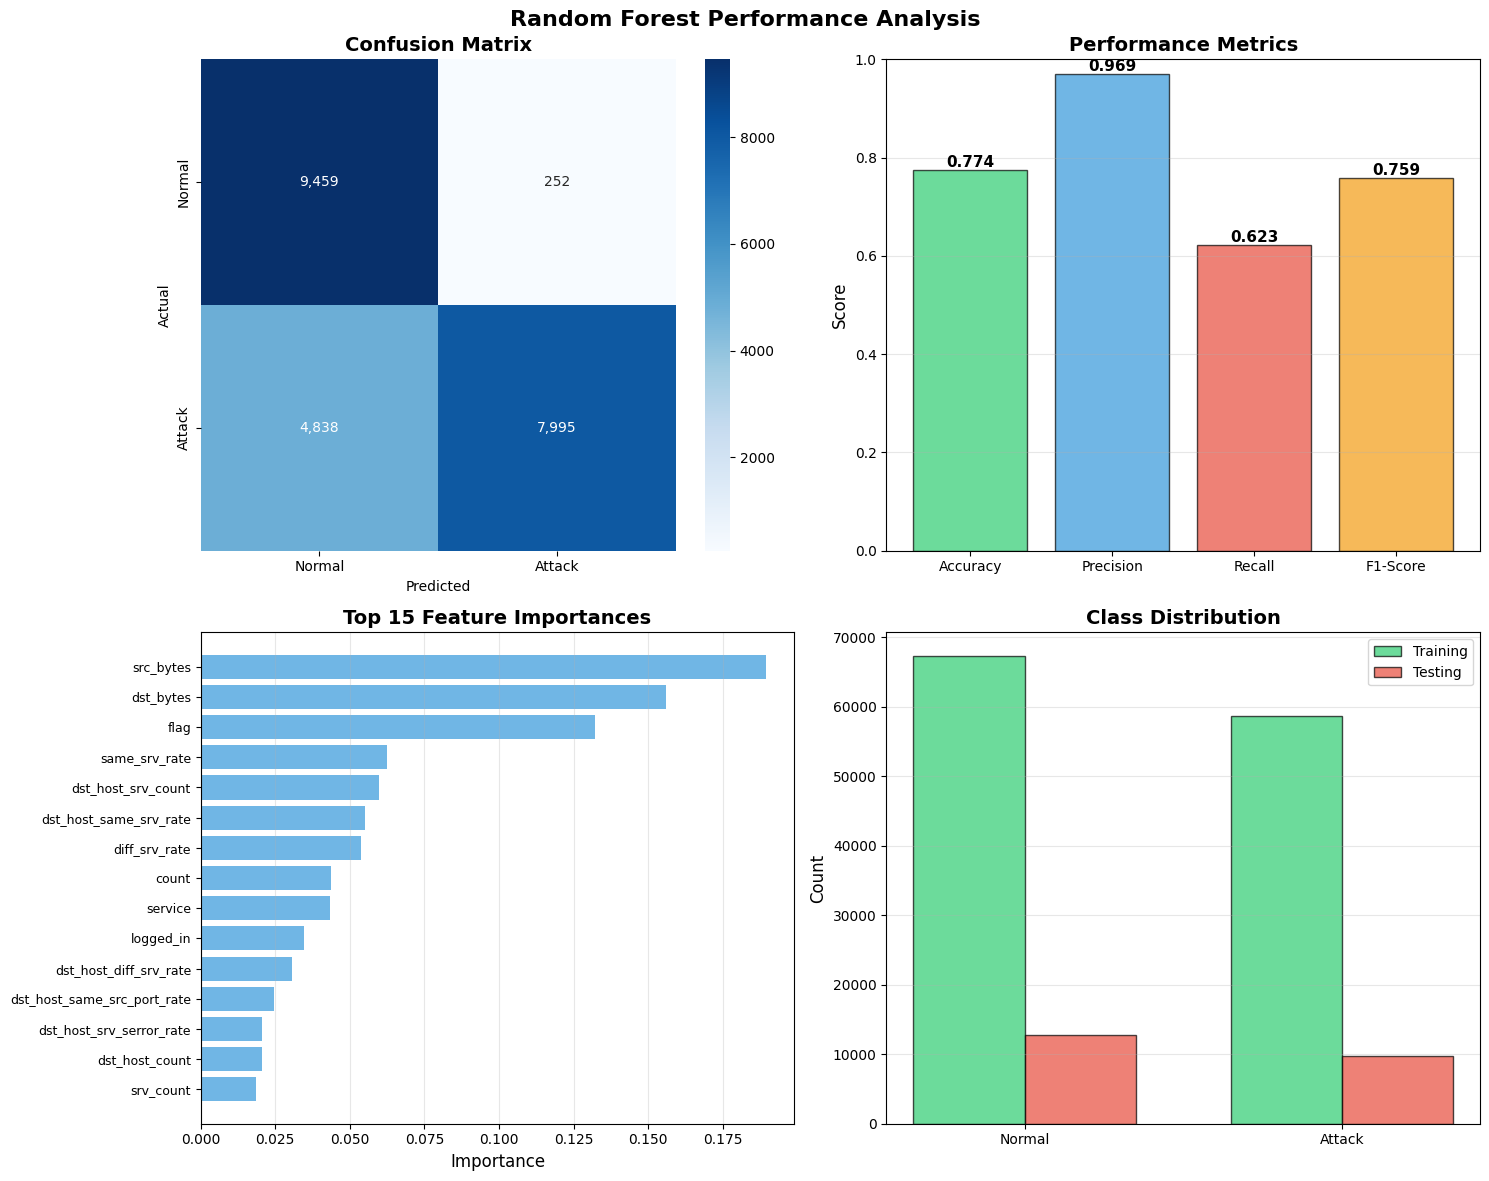

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=20,          # Maximum depth of trees
    min_samples_split=10,  # Minimum samples to split a node
    min_samples_leaf=4,    # Minimum samples at leaf node
    max_features='sqrt',   # Number of features for best split
    random_state=42,
    n_jobs=-1,            # Use all CPU cores
    verbose=0
)

print(f"\nModel parameters:")
print(f"  n_estimators: {rf_model.n_estimators}")
print(f"  max_depth: {rf_model.max_depth}")
print(f"  min_samples_split: {rf_model.min_samples_split}")
print(f"  min_samples_leaf: {rf_model.min_samples_leaf}")

# Train the model
start_time = time.time()
rf_model.fit(X_train, y_train)
train_time = time.time() - start_time

print(f"\n✓ Training completed in {train_time:.2f} seconds")

# ============================================================================
# STEP 4: EVALUATE MODEL
# ============================================================================
print("\n[4/5] Evaluating model...")

# Make predictions
y_pred = rf_model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n" + "="*80)
print("RANDOM FOREST RESULTS")
print("="*80)

print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"  F1-Score:  {f1:.4f}")

print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"{'':>15} Predicted Normal  Predicted Attack")
print(f"Actual Normal   {cm[0][0]:>15,}  {cm[0][1]:>15,}")
print(f"Actual Attack   {cm[1][0]:>15,}  {cm[1][1]:>15,}")

# ============================================================================
# STEP 5: FEATURE IMPORTANCE AND VISUALIZATION
# ============================================================================
print("\n[5/5] Analyzing feature importance...")

# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 15 Most Important Features:")
print(feature_importance.head(15).to_string(index=False))

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Random Forest Performance Analysis', fontsize=16, fontweight='bold')

# Plot 1: Confusion Matrix
ax1 = axes[0, 0]
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax1,
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
ax1.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax1.set_ylabel('Actual')
ax1.set_xlabel('Predicted')

# Plot 2: Metrics Bar Chart
ax2 = axes[0, 1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [accuracy, precision, recall, f1]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
bars = ax2.bar(metrics, values, color=colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Performance Metrics', fontsize=14, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 3: Top 15 Features
ax3 = axes[1, 0]
top_15 = feature_importance.head(15)
ax3.barh(range(len(top_15)), top_15['importance'], color='#3498db', alpha=0.7)
ax3.set_yticks(range(len(top_15)))
ax3.set_yticklabels(top_15['feature'], fontsize=9)
ax3.set_xlabel('Importance', fontsize=12)
ax3.set_title('Top 15 Feature Importances', fontsize=14, fontweight='bold')
ax3.invert_yaxis()
ax3.grid(axis='x', alpha=0.3)

# Plot 4: Class Distribution
ax4 = axes[1, 1]
train_dist = y_train.value_counts()
test_dist = y_test.value_counts()
x = np.arange(2)
width = 0.35
ax4.bar(x - width/2, train_dist.values, width, label='Training',
        color='#2ecc71', alpha=0.7, edgecolor='black')
ax4.bar(x + width/2, test_dist.values, width, label='Testing',
        color='#e74c3c', alpha=0.7, edgecolor='black')
ax4.set_ylabel('Count', fontsize=12)
ax4.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(['Normal', 'Attack'])
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()


In [ ]:
def create_domain_features(df):
    """Create network intrusion detection specific features"""
    df_new = df.copy()

    # 1. TRAFFIC VOLUME FEATURES
    df_new['total_bytes'] = df_new['src_bytes'] + df_new['dst_bytes']
    df_new['byte_ratio'] = np.where(df_new['dst_bytes'] != 0,
                                     df_new['src_bytes'] / df_new['dst_bytes'], 0)
    df_new['bytes_per_second'] = np.where(df_new['duration'] != 0,
                                           df_new['total_bytes'] / df_new['duration'], 0)

    # 2. CONNECTION PATTERNS
    df_new['srv_ratio'] = np.where(df_new['count'] != 0,
                                    df_new['srv_count'] / df_new['count'], 0)
    df_new['connection_density'] = df_new['count'] * df_new['srv_count']

    # 3. ERROR ANALYSIS
    df_new['total_error_rate'] = (df_new['serror_rate'] + df_new['rerror_rate'] +
                                   df_new['srv_serror_rate'] + df_new['srv_rerror_rate']) / 4
    df_new['error_variance'] = df_new[['serror_rate', 'rerror_rate',
                                        'srv_serror_rate', 'srv_rerror_rate']].var(axis=1)

    # 4. HOST-BASED PATTERNS
    df_new['dst_host_diversity'] = (df_new['dst_host_diff_srv_rate'] +
                                     df_new['dst_host_srv_diff_host_rate']) / 2
    df_new['dst_host_error_ratio'] = (df_new['dst_host_serror_rate'] +
                                       df_new['dst_host_rerror_rate']) / 2

    # 5. SECURITY INDICATORS
    df_new['security_score'] = (df_new['num_compromised'] + df_new['num_root'] +
                                df_new['num_file_creations'] + df_new['num_shells'])
    df_new['login_failure_ratio'] = np.where(df_new['logged_in'] == 1, 0,
                                              df_new['num_failed_logins'])

    # 6. ANOMALY INDICATORS
    df_new['is_guest_and_failed'] = df_new['is_guest_login'] * df_new['num_failed_logins']
    df_new['urgent_and_hot'] = df_new['urgent'] * df_new['hot']

    # 7. STATISTICAL FEATURES
    numeric_cols = ['src_bytes', 'dst_bytes', 'count', 'srv_count']
    for col in numeric_cols:
        df_new[f'{col}_log'] = np.log1p(df_new[col])
        df_new[f'{col}_sqrt'] = np.sqrt(df_new[col])

    # 8. INTERACTION FEATURES
    df_new['protocol_service_interaction'] = df_new['protocol_type'] * df_new['service']
    df_new['flag_error_interaction'] = df_new['flag'] * df_new['total_error_rate']

    return df_new

df_train_eng = create_domain_features(df_train)
df_test_eng = create_domain_features(df_test)

num_new_features = df_train_eng.shape[1] - df_train.shape[1]
print(f"✓ Created {num_new_features} new domain-specific features")
print(f"  Total features: {df_train_eng.shape[1] - 2} (excluding attack_type, is_attack)")

# ============================================================================
# STEP 4: PREPARE FEATURES
# ============================================================================
print("\n[STEP 4/7] Preparing features...")

# Separate features and target
X_train = df_train_eng.drop(['class', 'is_attack'], axis=1)
y_train = df_train_eng['is_attack']

X_test = df_test_eng.drop(['class', 'is_attack'], axis=1)
y_test = df_test_eng['is_attack']

# Handle inf and nan
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print(f"✓ Feature matrix shape: {X_train.shape}")
print(f"✓ Target distribution - Train: {y_train.value_counts().to_dict()}")
print(f"✓ Target distribution - Test: {y_test.value_counts().to_dict()}")

# ============================================================================
# STEP 5: TRAIN BASELINE RANDOM FOREST
# ============================================================================
print("\n[STEP 5/7] Training baseline Random Forest...")

# Default Random Forest
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

start_time = time.time()
rf_baseline.fit(X_train, y_train)
baseline_train_time = time.time() - start_time

# Predictions
y_pred_baseline = rf_baseline.predict(X_test)
y_pred_proba_baseline = rf_baseline.predict_proba(X_test)[:, 1]

# Metrics
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline)
baseline_recall = recall_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline)
baseline_auc = roc_auc_score(y_test, y_pred_proba_baseline)

print(f"\n✓ Baseline Random Forest Results:")
print(f"  Training time: {baseline_train_time:.2f} seconds")
print(f"  Accuracy:  {baseline_accuracy:.4f}")
print(f"  Precision: {baseline_precision:.4f}")
print(f"  Recall:    {baseline_recall:.4f}")
print(f"  F1-Score:  {baseline_f1:.4f}")
print(f"  AUC-ROC:   {baseline_auc:.4f}")

# ============================================================================
# STEP 6: FEATURE SELECTION
# ============================================================================
print("\n[STEP 6/7] Performing feature selection...")

# Use the baseline model for feature selection
selector = SelectFromModel(rf_baseline, threshold='median', prefit=True)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

# Get selected feature names
selected_features_mask = selector.get_support()
selected_feature_names = X_train.columns[selected_features_mask].tolist()

print(f"✓ Selected {X_train_selected.shape[1]} features from {X_train.shape[1]}")
print(f"  Reduction: {(1 - X_train_selected.shape[1]/X_train.shape[1])*100:.1f}%")
print(f"\nTop 10 most important features:")
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_baseline.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance.head(10).to_string(index=False))

# ============================================================================
# STEP 7: HYPERPARAMETER TUNING
# ============================================================================
print("\n[STEP 7/7] Hyperparameter tuning with GridSearchCV...")

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

print(f"Testing {np.prod([len(v) for v in param_grid.values()])} combinations...")

# Grid Search with Cross-Validation
rf_grid = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    cv=3,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

start_time = time.time()
grid_search.fit(X_train_selected, y_train)
grid_time = time.time() - start_time

print(f"\n✓ Grid Search completed in {grid_time:.2f} seconds")
print(f"\nBest parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest cross-validation F1-Score: {grid_search.best_score_:.4f}")

# ============================================================================
# FINAL MODEL: TRAIN WITH BEST PARAMETERS
# ============================================================================
print("\n" + "="*100)
print("TRAINING FINAL OPTIMIZED RANDOM FOREST")
print("="*100)

# Best model from grid search
rf_optimized = grid_search.best_estimator_

# Train on selected features
start_time = time.time()
rf_optimized.fit(X_train_selected, y_train)
final_train_time = time.time() - start_time

# Predictions
y_pred_optimized = rf_optimized.predict(X_test_selected)
y_pred_proba_optimized = rf_optimized.predict_proba(X_test_selected)[:, 1]

# Metrics
optimized_accuracy = accuracy_score(y_test, y_pred_optimized)
optimized_precision = precision_score(y_test, y_pred_optimized)
optimized_recall = recall_score(y_test, y_pred_optimized)
optimized_f1 = f1_score(y_test, y_pred_optimized)
optimized_auc = roc_auc_score(y_test, y_pred_proba_optimized)

print(f"\n✓ Final model trained in {final_train_time:.2f} seconds")

print("\n" + "="*100)
print("FINAL RESULTS - OPTIMIZED RANDOM FOREST")
print("="*100)

print(f"\nModel Configuration:")
print(f"  Features used: {X_train_selected.shape[1]}")
print(f"  n_estimators: {rf_optimized.n_estimators}")
print(f"  max_depth: {rf_optimized.max_depth}")
print(f"  min_samples_split: {rf_optimized.min_samples_split}")
print(f"  min_samples_leaf: {rf_optimized.min_samples_leaf}")
print(f"  max_features: {rf_optimized.max_features}")

print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {optimized_accuracy:.4f} ({optimized_accuracy*100:.2f}%)")
print(f"  Precision: {optimized_precision:.4f} ({optimized_precision*100:.2f}%)")
print(f"  Recall:    {optimized_recall:.4f} ({optimized_recall*100:.2f}%)")
print(f"  F1-Score:  {optimized_f1:.4f}")
print(f"  AUC-ROC:   {optimized_auc:.4f}")

print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_optimized, target_names=['Normal', 'Attack']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_optimized)
print(f"\nConfusion Matrix:")
print(f"{'':>15} Predicted Normal  Predicted Attack")
print(f"Actual Normal   {cm[0][0]:>15,}  {cm[0][1]:>15,}")
print(f"Actual Attack   {cm[1][0]:>15,}  {cm[1][1]:>15,}")

# Improvement calculation
improvement_acc = ((optimized_accuracy - baseline_accuracy) / baseline_accuracy) * 100
improvement_f1 = ((optimized_f1 - baseline_f1) / baseline_f1) * 100

print(f"\nImprovement over Baseline:")
print(f"  Accuracy: {baseline_accuracy:.4f} → {optimized_accuracy:.4f} ({improvement_acc:+.2f}%)")
print(f"  F1-Score: {baseline_f1:.4f} → {optimized_f1:.4f} ({improvement_f1:+.2f}%)")

# ============================================================================
# CROSS-VALIDATION ANALYSIS
# ============================================================================
print("\n" + "="*100)
print("CROSS-VALIDATION ANALYSIS")
print("="*100)

cv_scores = cross_val_score(rf_optimized, X_train_selected, y_train,
                            cv=5, scoring='accuracy', n_jobs=-1)

print(f"\n5-Fold Cross-Validation Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# ============================================================================
# VISUALIZATION
# ============================================================================
print("\n" + "="*100)
print("CREATING VISUALIZATIONS")
print("="*100)

fig = plt.figure(figsize=(18, 12))

# Plot 1: Model Comparison (Baseline vs Optimized)
ax1 = plt.subplot(3, 3, 1)
models = ['Baseline RF', 'Optimized RF']
metrics_comparison = {
    'Accuracy': [baseline_accuracy, optimized_accuracy],
    'Precision': [baseline_precision, optimized_precision],
    'Recall': [baseline_recall, optimized_recall],
    'F1-Score': [baseline_f1, optimized_f1]
}

x = np.arange(len(models))
width = 0.2
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

for i, (metric, values) in enumerate(metrics_comparison.items()):
    ax1.bar(x + i*width, values, width, label=metric, color=colors[i], alpha=0.8)

ax1.set_ylabel('Score', fontsize=11)
ax1.set_title('Baseline vs Optimized Random Forest', fontsize=13, fontweight='bold')
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(models)
ax1.set_ylim([0, 1])
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Feature Importance (Top 20)
ax2 = plt.subplot(3, 3, 2)
top_features = feature_importance.head(20)
ax2.barh(range(len(top_features)), top_features['importance'], color='#3498db', alpha=0.7)
ax2.set_yticks(range(len(top_features)))
ax2.set_yticklabels(top_features['feature'], fontsize=8)
ax2.set_xlabel('Importance', fontsize=11)
ax2.set_title('Top 20 Feature Importances', fontsize=13, fontweight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

# Plot 3: Confusion Matrix Heatmap
ax3 = plt.subplot(3, 3, 3)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax3,
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'],
            cbar_kws={'label': 'Count'})
ax3.set_title('Confusion Matrix - Optimized RF', fontsize=13, fontweight='bold')
ax3.set_ylabel('Actual', fontsize=11)
ax3.set_xlabel('Predicted', fontsize=11)

# Plot 4: ROC Curve
ax4 = plt.subplot(3, 3, 4)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_optimized)
ax4.plot(fpr, tpr, linewidth=2, label=f'RF (AUC = {optimized_auc:.4f})', color='#e74c3c')
ax4.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax4.set_xlabel('False Positive Rate', fontsize=11)
ax4.set_ylabel('True Positive Rate', fontsize=11)
ax4.set_title('ROC Curve', fontsize=13, fontweight='bold')
ax4.legend(loc='lower right')
ax4.grid(True, alpha=0.3)

# Plot 5: Cross-Validation Scores
ax5 = plt.subplot(3, 3, 5)
ax5.bar(range(1, 6), cv_scores, color='#2ecc71', alpha=0.7, edgecolor='black')
ax5.axhline(y=cv_scores.mean(), color='r', linestyle='--', linewidth=2, label='Mean')
ax5.set_xlabel('Fold', fontsize=11)
ax5.set_ylabel('Accuracy', fontsize=11)
ax5.set_title('5-Fold Cross-Validation Scores', fontsize=13, fontweight='bold')
ax5.set_ylim([0, 1])
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

# Plot 6: Metrics Breakdown
ax6 = plt.subplot(3, 3, 6)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [optimized_accuracy, optimized_precision, optimized_recall, optimized_f1]
bars = ax6.barh(metrics_names, metrics_values, color=colors, alpha=0.8, edgecolor='black')
ax6.set_xlabel('Score', fontsize=11)
ax6.set_title('Final Model Metrics', fontsize=13, fontweight='bold')
ax6.set_xlim([0, 1])
ax6.grid(axis='x', alpha=0.3)
for bar, value in zip(bars, metrics_values):
    width = bar.get_width()
    ax6.text(width, bar.get_y() + bar.get_height()/2., f'{value:.4f}',
             ha='left', va='center', fontsize=10, fontweight='bold', color='black')

# Plot 7: Training Time Comparison
ax7 = plt.subplot(3, 3, 7)
times = [baseline_train_time, final_train_time]
labels = ['Baseline\nRF', 'Optimized\nRF']
bars = ax7.bar(labels, times, color=['#95a5a6', '#3498db'], alpha=0.8, edgecolor='black')
ax7.set_ylabel('Time (seconds)', fontsize=11)
ax7.set_title('Training Time Comparison', fontsize=13, fontweight='bold')
ax7.grid(axis='y', alpha=0.3)
for bar, time_val in zip(bars, times):
    height = bar.get_height()
    ax7.text(bar.get_x() + bar.get_width()/2., height,
             f'{time_val:.2f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 8: Number of Trees Analysis (from grid search results)
ax8 = plt.subplot(3, 3, 8)
if 'n_estimators' in grid_search.best_params_:
    # Show how different n_estimators performed
    results_df = pd.DataFrame(grid_search.cv_results_)
    n_est_results = results_df.groupby('param_n_estimators')['mean_test_score'].mean()
    ax8.plot(n_est_results.index, n_est_results.values, marker='o', linewidth=2,
             markersize=8, color='#e74c3c')
    ax8.set_xlabel('Number of Trees', fontsize=11)
    ax8.set_ylabel('Mean CV Score', fontsize=11)
    ax8.set_title('Trees vs Performance', fontsize=13, fontweight='bold')
    ax8.grid(True, alpha=0.3)
    ax8.axvline(x=rf_optimized.n_estimators, color='g', linestyle='--',
                label=f'Best: {rf_optimized.n_estimators}')
    ax8.legend()

# Plot 9: Feature Selection Impact
ax9 = plt.subplot(3, 3, 9)
feature_counts = [X_train.shape[1], X_train_selected.shape[1]]
labels = ['All Features', 'Selected Features']
colors_pie = ['#e74c3c', '#2ecc71']
wedges, texts, autotexts = ax9.pie(feature_counts, labels=labels, autopct='%1.0f%%',
                                     colors=colors_pie, startangle=90)
ax9.set_title(f'Feature Selection\n({X_train_selected.shape[1]}/{X_train.shape[1]} features)',
              fontsize=13, fontweight='bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

plt.tight_layout()
plt.savefig('/home/claude/random_forest_results.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved as 'random_forest_results.png'")

NameError: name 'df_train' is not defined

In [ ]:
print("\n[4/6] Finding optimal K value...")

# Test different K values
k_values = [3, 5, 7, 9, 11, 15, 19, 25]
k_results = []

print(f"\nTesting K values: {k_values}")
print("This may take a few minutes...")

# Use a sample for faster K selection
sample_size = 5000
sample_indices = np.random.choice(len(X_train_scaled), sample_size, replace=False)
X_train_sample = X_train_scaled[sample_indices]
y_train_sample = y_train.iloc[sample_indices]

for k in k_values:
    print(f"  Testing K={k}...", end=' ')
    start_time = time.time()

    knn = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_sample, y_train_sample)

    # Evaluate on a test sample
    test_sample_size = 2000
    test_indices = np.random.choice(len(X_test_scaled), test_sample_size, replace=False)
    X_test_sample = X_test_scaled[test_indices]
    y_test_sample = y_test.iloc[test_indices]

    y_pred = knn.predict(X_test_sample)
    acc = accuracy_score(y_test_sample, y_pred)
    f1 = f1_score(y_test_sample, y_pred)

    elapsed = time.time() - start_time
    k_results.append({
        'k': k,
        'accuracy': acc,
        'f1_score': f1,
        'time': elapsed
    })

    print(f"Accuracy: {acc:.4f}, F1: {f1:.4f}, Time: {elapsed:.2f}s")

# Find best K
k_results_df = pd.DataFrame(k_results)
best_k_idx = k_results_df['f1_score'].idxmax()
best_k = k_results_df.loc[best_k_idx, 'k']

print(f"\n✓ Optimal K value: {best_k} (F1-Score: {k_results_df.loc[best_k_idx, 'f1_score']:.4f})")

# ============================================================================
# STEP 5: TRAIN KNN WITH OPTIMAL K
# ============================================================================
print(f"\n[5/6] Training KNN with K={best_k}...")

# Use subset for faster training (KNN is expensive on large datasets)
train_size = 10000
train_indices = np.random.choice(len(X_train_scaled), train_size, replace=False)
X_train_subset = X_train_scaled[train_indices]
y_train_subset = y_train.iloc[train_indices]

# Create KNN model with optimal K
knn_model = KNeighborsClassifier(
    n_neighbors=int(best_k),
    weights='distance',      # Weight by inverse distance
    algorithm='auto',        # Choose best algorithm automatically
    metric='minkowski',      # Euclidean distance
    p=2,                     # p=2 means Euclidean
    n_jobs=-1               # Use all CPU cores
)

print(f"\nModel parameters:")
print(f"  n_neighbors: {knn_model.n_neighbors}")
print(f"  weights: {knn_model.weights}")
print(f"  algorithm: {knn_model.algorithm}")
print(f"  metric: {knn_model.metric}")
print(f"  Training samples: {train_size:,}")

# Train the model
start_time = time.time()
knn_model.fit(X_train_subset, y_train_subset)
train_time = time.time() - start_time

print(f"\n✓ Training completed in {train_time:.2f} seconds")

# ============================================================================
# STEP 6: EVALUATE MODEL
# ============================================================================
print("\n[6/6] Evaluating model...")

# Make predictions
print("Making predictions (this may take a moment)...")
start_time = time.time()
y_pred = knn_model.predict(X_test_scaled)
prediction_time = time.time() - start_time

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n" + "="*80)
print("K-NEAREST NEIGHBORS RESULTS")
print("="*80)

print(f"\nModel Configuration:")
print(f"  K (neighbors): {knn_model.n_neighbors}")
print(f"  Distance metric: {knn_model.metric}")
print(f"  Weighting: {knn_model.weights}")
print(f"  Training samples: {train_size:,}")

print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"  Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"  F1-Score:  {f1:.4f}")

print(f"\nTiming:")
print(f"  Training time: {train_time:.2f} seconds")
print(f"  Prediction time: {prediction_time:.2f} seconds")
print(f"  Avg prediction per sample: {prediction_time/len(y_test)*1000:.2f} ms")

print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Attack']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"{'':>15} Predicted Normal  Predicted Attack")
print(f"Actual Normal   {cm[0][0]:>15,}  {cm[0][1]:>15,}")
print(f"Actual Attack   {cm[1][0]:>15,}  {cm[1][1]:>15,}")


[4/6] Finding optimal K value...

Testing K values: [3, 5, 7, 9, 11, 15, 19, 25]
This may take a few minutes...
  Testing K=3... Accuracy: 0.7945, F1: 0.7876, Time: 0.12s
  Testing K=5... Accuracy: 0.8000, F1: 0.8004, Time: 0.08s
  Testing K=7... Accuracy: 0.8065, F1: 0.7969, Time: 0.08s
  Testing K=9... Accuracy: 0.8085, F1: 0.8033, Time: 0.08s
  Testing K=11... Accuracy: 0.8040, F1: 0.7915, Time: 0.08s
  Testing K=15... Accuracy: 0.7885, F1: 0.7722, Time: 0.08s
  Testing K=19... Accuracy: 0.7980, F1: 0.7811, Time: 0.10s
  Testing K=25... Accuracy: 0.7935, F1: 0.7830, Time: 0.09s

✓ Optimal K value: 9 (F1-Score: 0.8033)

[5/6] Training KNN with K=9...

Model parameters:
  n_neighbors: 9
  weights: distance
  algorithm: auto
  metric: minkowski
  Training samples: 10,000

✓ Training completed in 0.00 seconds

[6/6] Evaluating model...
Making predictions (this may take a moment)...

K-NEAREST NEIGHBORS RESULTS

Model Configuration:
  K (neighbors): 9
  Distance metric: minkowski
  Weig